# Análisis de Clústeres para Optimización de Rutas de Flota

Este cuaderno tiene como objetivo principal la optimización de rutas de flotas mediante la aplicación de técnicas de clustering (agrupamiento). El proceso se divide en varias fases clave:

1.  **Carga y Preparación de Datos**: Importación de datos de viajes y cálculo de distancias y tiempos de espera para categorizar los viajes.
2.  **Selección de la k (Número de Estaciones/Clústeres)**: Determinación del número óptimo de clústeres (`k`) utilizando métricas como el Silhouette Score y el análisis de la cantidad de viajes 'fuera de radio'.
3.  **Determinación de Centroides y Asignación Espacial**: Cálculo de los centroides para los clústeres seleccionados, ajustándolos a la red vial real y reasignando los viajes a estos centroides corregidos.
4.  **Evaluación y Filtrado Post-Clusterización**: Análisis de la calidad de los clústeres resultantes, identificación de viajes 'perdidos' (aquellos que no pueden ser cubiertos eficientemente por los clústeres) y visualización de los resultados.

El objetivo final es identificar ubicaciones estratégicas para estaciones de flota que minimicen la distancia a los puntos de origen y destino de los viajes, optimizando así la eficiencia operativa.

## Selección de la k (número de estaciones)

En esta sección, nos enfocamos en determinar el número óptimo de clústeres (`k`) para agrupar las coordenadas de origen y destino de los viajes. Un `k` apropiado es crucial para balancear la granularidad de las estaciones con la cobertura eficiente de los viajes.

Para ello, utilizaremos:
*   **KMeans**: Algoritmo de clustering para agrupar las coordenadas.
*   **Análisis de "Viajes fuera de radio"**: Una métrica personalizada que cuantifica cuántos viajes quedarían fuera de un radio de servicio razonable alrededor de sus clústeres asignados.
*   **Silhouette Score**: Una métrica estándar de evaluación de la calidad de los clústeres, que mide la cohesión dentro de los clústeres y la separación entre ellos.

Primero, preparamos el DataFrame `combined_coords_df` que contiene las coordenadas de latitud y longitud, junto con información sobre el tipo de viaje y el tiempo de espera. Luego, aplicamos el algoritmo K-Means a estas coordenadas para varios valores de `k` (número de clústeres), almacenando los resultados de la asignación de clústeres para cada `k` en nuevas columnas.

In [ ]:
import pandas as pd
colab=True
df = pd.read_csv('rome_clean.csv') if colab == True else pd.read_csv('/data/processed/rome_clean.csv')
df

In [ ]:
coords_df = df[['lonO', 'latO', 'lonD', 'latD', 'idS', 'dis']].copy()

def categorize_distance(dis):
    if dis < 2500:
        return 'corto'
    elif dis < 5000:
        return 'medio'
    else:
        return 'largo'

def wait(dis):
    if dis == 'corto':
        return 300
    elif dis == 'medio':
        return 420
    else:
        return 600

coords_df['type'] = coords_df['dis'].apply(categorize_distance)
coords_df['wait'] = coords_df['type'].apply(wait)
coords_df

Esta función calcula cuántos viajes se considerarían "fuera de radio" para cada valor de `k`. Un viaje se considera fuera de radio si la distancia entre su punto de origen/destino y el centroide de su clúster asignado excede una distancia máxima caminable. Esta distancia máxima se calcula en función del tiempo de espera (`wait`) y una velocidad de caminata predefinida (5 km/h).

In [ ]:
origin_df = coords_df[['lonO', 'latO', 'idS', 'dis', 'type', 'wait']].copy()
origin_df.rename(columns={'lonO': 'lon', 'latO': 'lat'}, inplace=True)
origin_df['origin'] = True

destination_df = coords_df[['lonD', 'latD', 'idS', 'dis', 'type', 'wait']].copy()
destination_df.rename(columns={'lonD': 'lon', 'latD': 'lat'}, inplace=True)
destination_df['origin'] = False

combined_coords_df = pd.concat([origin_df, destination_df], ignore_index=True)
combined_coords_df

In [30]:
from sklearn.cluster import KMeans
from tqdm import tqdm

def clusterizar_coordenadas(df, coords_cols, k_values=[100,150,200,250,300,350,400], random_state=42):
    """
    Clusteriza un DataFrame usando KMeans para varios valores de k con barra de progreso.

    Args:
        df (pd.DataFrame): DataFrame con las coordenadas.
        coords_cols (list): Lista con los nombres de las columnas de coordenadas, e.g., ['lat','lon'].
        k_values (list): Lista de valores de k a probar.
        random_state (int): Semilla para reproducibilidad.

    Returns:
        pd.DataFrame: DataFrame con nuevas columnas cluster_k para cada valor de k.
    """
    for k in tqdm(k_values, desc="Clustering"):
        kmeans = KMeans(n_clusters=k, random_state=random_state)
        df[f'cluster_{k}'] = kmeans.fit_predict(df[coords_cols])
    return df

In [31]:
k_values = list(range(150, 310, 10))
combined_coords_df = clusterizar_coordenadas(combined_coords_df, coords_cols=['lat','lon'], k_values=k_values)

Clustering: 100%|██████████| 16/16 [00:12<00:00,  1.32it/s]


In [32]:
import numpy as np
from tqdm import tqdm

def haversine_dist(lat1, lon1, lat2, lon2):
    """
    Calcula la distancia Haversine en metros entre dos puntos (lat, lon).
    """
    R = 6371000  # Radio de la Tierra en metros
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)

    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

def viajes_fuera_de_radio(df, coords_cols=['lat','lon'], k_values=[100,150,200,250,300,350,400], velocidad_kmh=5):
    resultados = {}

    for k in tqdm(k_values, total=len(k_values)):
        cluster_col = f'cluster_{k}'
        fuera = 0

        # Obtener centroides
        centroides = df.groupby(cluster_col)[coords_cols].mean()

        for idx, row in tqdm(df.iterrows(), total=len(df)):
            centroide = centroides.loc[row[cluster_col]]
            distancia_m = haversine_dist(row[coords_cols[0]], row[coords_cols[1]],
                                        centroide[coords_cols[0]], centroide[coords_cols[1]])

            max_dist = (velocidad_kmh * 1000 / 3600) * row['wait']

            if distancia_m > max_dist:
                fuera += 1

        resultados[k] = fuera

    return resultados


In [ ]:
combined_coords_results = viajes_fuera_de_radio(combined_coords_df, k_values=k_values)
combined_coords_results

In [34]:
from sklearn.metrics import silhouette_score
from tqdm import tqdm

def calcular_silhouette(df, coords_cols=['lat','lon'], k_values=[100,150,200,250,300,350,400]):
    """
    Calcula el silhouette score para cada clustering guardado en cluster_k.

    Args:
        df (pd.DataFrame): DataFrame con las coordenadas y las columnas cluster_k.
        coords_cols (list): Columnas de lat/lon.
        k_values (list): Valores de k.

    Returns:
        dict: {k: silhouette score}
    """
    scores = {}
    X = df[coords_cols].values

    for k in tqdm(k_values, total=len(k_values)):
        cluster_col = f'cluster_{k}'
        labels = df[cluster_col].values
        if len(set(labels)) > 1:  # Silhouette necesita al menos 2 clusters
            score = silhouette_score(X, labels)
        else:
            score = 0
        scores[k] = score
    return scores

El Silhouette Score mide qué tan similares son los objetos dentro de su propio clúster (cohesión) en comparación con otros clústeres (separación). Un valor alto indica que el objeto está bien emparejado con su propio clúster y mal emparejado con los clústeres vecinos. Calculamos este score para cada valor de `k` para evaluar la calidad de los agrupamientos.

In [35]:
sil_scores = calcular_silhouette(combined_coords_df, k_values=k_values)

100%|██████████| 16/16 [00:46<00:00,  2.90s/it]


In [40]:
import plotly.graph_objects as go

def plot_silhouette_vs_viajes_pro(k_values, silhouette_scores, viajes_fuera, k_highlight=190):
    """
    Grafica Silhouette Score y Viajes fuera de radio con estilo profesional en tonos azules.
    Marca específicamente el valor óptimo (por defecto 190).

    Args:
        k_values (list): Lista de valores de k.
        silhouette_scores (dict): Diccionario {k: score}.
        viajes_fuera (dict): Diccionario {k: número de viajes perdidos}.
        k_highlight (int): El valor de k a resaltar (ej. 190).
    """

    # 1. PREPARACIÓN DE DATOS
    # Aseguramos que los datos estén alineados en listas
    y_sil = [silhouette_scores[k] for k in k_values]
    y_viajes = [viajes_fuera[k] for k in k_values]

    # Valores específicos para el punto destacado (k=190)
    val_sil_opt = silhouette_scores.get(k_highlight)
    val_viajes_opt = viajes_fuera.get(k_highlight)

    # 2. DEFINICIÓN DE COLORES (Paleta Profesional Azul)
    color_sil = '#003f5c'   # Azul profundo / Navy (Silhouette)
    color_via = '#00a0c8'   # Azul cián / Tecnológico (Viajes)
    color_highlight = '#58508d' # Un tono de contraste sutil para la línea vertical (o gris)

    fig = go.Figure()

    # ---------------------------------------------------------
    # TRAZA 1: Silhouette Score (Eje Izquierdo)
    # ---------------------------------------------------------
    fig.add_trace(go.Scatter(
        x=k_values, y=y_sil,
        name='Silhouette Score',
        mode='lines',
        line=dict(color=color_sil, width=3),
        yaxis='y1'
    ))

    # ---------------------------------------------------------
    # TRAZA 2: Viajes fuera de radio (Eje Derecho)
    # ---------------------------------------------------------
    fig.add_trace(go.Scatter(
        x=k_values, y=y_viajes,
        name='Viajes fuera de radio',
        mode='lines',
        line=dict(color=color_via, width=3, dash='solid'), # Puedes usar 'dot' si prefieres contraste
        yaxis='y2'
    ))

    # ---------------------------------------------------------
    # HIGHLIGHT: Marcado del k=190
    # ---------------------------------------------------------
    if val_sil_opt is not None and val_viajes_opt is not None:
        # Línea vertical guía
        fig.add_vline(x=k_highlight, line_width=1, line_dash="dash", line_color="gray", opacity=0.7)

        # Punto destacado en Silhouette
        fig.add_trace(go.Scatter(
            x=[k_highlight], y=[val_sil_opt],
            mode='markers',
            marker=dict(color=color_sil, size=12, line=dict(color='white', width=2)),
            showlegend=False, name=f'Silhuette k={k_highlight}', yaxis='y1'
        ))

        # Punto destacado en Viajes
        fig.add_trace(go.Scatter(
            x=[k_highlight], y=[val_viajes_opt],
            mode='markers',
            marker=dict(color=color_via, size=12, line=dict(color='white', width=2)),
            showlegend=False, name=f'Pérdidas k={k_highlight}', yaxis='y2'
        ))

        # Anotación (Texto) para Silhouette
        fig.add_annotation(
            x=k_highlight, y=val_sil_opt,
            text=f"<b>Sil: {val_sil_opt:.3f}</b>",
            showarrow=True, arrowhead=2, ax=-40, ay=-30,
            font=dict(color=color_sil, size=11), yref='y1'
        )

        # Anotación (Texto) para Viajes
        fig.add_annotation(
            x=k_highlight, y=val_viajes_opt,
            text=f"<b>Pérdidas: {int(val_viajes_opt)}</b>",
            showarrow=True,
            arrowhead=2,
            ax=40,    # Lo desplazamos un poco a la derecha para que no se pise con la otra
            ay=-60,   # <--- CAMBIO CLAVE: Valor negativo sube el texto
            font=dict(color=color_via, size=11),
            yref='y2'
        )

    # ---------------------------------------------------------
    # LAYOUT: Diseño y Ejes
    # ---------------------------------------------------------
    fig.update_layout(
        title=dict(
            text='<b>Compromiso entre Cohesión (Silhouette) y Cobertura Operativa</b>',
            font=dict(size=18, color='#333333')
        ),
        template='plotly_white', # Fondo blanco limpio
        hovermode="x unified",   # Al pasar el ratón muestra ambos valores
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        ),
        margin=dict(l=60, r=60, t=80, b=60),

        # Eje X
        xaxis=dict(
            title='Número de clústeres (k)',
            showgrid=False, # Rejilla vertical fuera para limpieza
            linecolor='black'
        ),

        # Eje Y1 (Izquierda - Silhouette)
        yaxis=dict(
            title='Silhouette Score',
            titlefont=dict(color=color_sil),
            tickfont=dict(color=color_sil),
            showgrid=True,
            gridcolor='lightgray',
            zeroline=False
        ),

        # Eje Y2 (Derecha - Viajes)
        yaxis2=dict(
            title='Viajes fuera de radio (Pérdidas)',
            titlefont=dict(color=color_via),
            tickfont=dict(color=color_via),
            anchor="x",
            overlaying="y",
            side="right",
            showgrid=False, # Para no ensuciar con doble rejilla
            zeroline=False
        )
    )

    fig.show()

# EJEMPLO DE USO (Asumiendo que tienes tus diccionarios):
# plot_silhouette_vs_viajes_pro(k_values, silhouette_scores_dict, viajes_fuera_dict, k_highlight=190)

Se genera un gráfico que compara el Silhouette Score y el número de viajes fuera de radio para diferentes valores de `k`. Este gráfico nos ayuda a visualizar el compromiso entre la cohesión de los clústeres (Silhouette Score) y la cobertura operativa (viajes fuera de radio). El objetivo es encontrar un punto de inflexión donde el Silhouette Score sea alto y el número de viajes fuera de radio sea bajo o se estabilice.

In [41]:
plot_silhouette_vs_viajes_pro(k_values, sil_scores, combined_coords_results)

Elegimos **190** como el número óptimo de clústeres (`k`) basándonos en el gráfico anterior. En este punto, el Silhouette Score parece estancarse, indicando que añadir más clústeres no mejora significativamente la cohesión interna o la separación. Al mismo tiempo, la curva de "viajes fuera de radio" muestra una reducción importante que empieza a estabilizarse. A partir de `k=220`, el número de viajes fuera de radio comienza a crecer marginalmente, y consideramos que `190` ya es un número adecuado de estaciones que permite una buena cobertura sin generar una cantidad excesiva de infraestructura.

## Determinación de Centroides y Asignación Espacial de los Viajes con sus Clústeres

Una vez seleccionado el número óptimo de clústeres (`k=190`), esta sección se enfoca en refinar la ubicación de los centroides y reasignar los viajes a estos puntos optimizados. El proceso incluye:

1.  **Reducción de Dimensiones del DataFrame**: Seleccionar solo las columnas relevantes para el análisis del clúster final (`cluster_190`).
2.  **Cálculo de Centroides Iniciales**: Determinar las coordenadas medias de cada clúster.
3.  **Agrupación de Centroides Cercanos**: Fusionar centroides que están muy próximos entre sí para consolidar las ubicaciones de las estaciones y calcular un nuevo centroide ponderado.
4.  **Ajuste de Centroides a la Red Vial**: Mover los centroides para que no caigan en zonas restringidas (como edificios o ríos) y se "peguen" a la red de calles real, utilizando datos de OpenStreetMap.
5.  **Reasignación Final de Viajes**: Asignar cada punto de origen y destino de los viajes al centroide corregido más cercano, creando así el `clusterFinal`.

In [ ]:
combined_coords_df = combined_coords_df[['lon', 'lat', 'idS', 'type', 'origin', 'cluster_190']]
combined_coords_df

Aquí, seleccionamos únicamente las columnas esenciales del DataFrame `combined_coords_df` (`lon`, `lat`, `idS`, `type`, `origin`, `cluster_190`) para simplificar el conjunto de datos y centrarnos en la información relevante para el `cluster_190` que hemos elegido como óptimo.

In [ ]:
import folium
import pandas as pd

cluster_col = 'cluster_190'
coords_cols = ['lat', 'lon']

# Calcular centroides
centroides = combined_coords_df.groupby(cluster_col)[coords_cols].mean().reset_index()

# Crear mapa centrado en los puntos
mapa = folium.Map(location=[combined_coords_df['lat'].mean(), combined_coords_df['lon'].mean()], zoom_start=13)

# Colores para clusters
colores = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightblue', 'cadetblue', 'darkgreen', 'pink']

# Añadir centroides
for i, row in centroides.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"Cluster {row[cluster_col]}",
        icon=folium.Icon(color=colores[i % len(colores)], icon='star')
    ).add_to(mapa)

# Añadir puntos
for i, row in combined_coords_df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=3,
        color=colores[row['cluster_190'] % len(colores)],
        fill=True,
        fill_opacity=0.6
    ).add_to(mapa)

mapa


Se utiliza la biblioteca `folium` para crear un mapa interactivo que muestra los centroides de los clústeres y todos los puntos de origen/destino asignados a ellos. Cada clúster se representa con un color distinto, lo que permite una visualización rápida de la distribución espacial de los agrupamientos iniciales.

In [ ]:
centroides.rename({'cluster_190': 'cluster'}, axis=1, inplace=True)

In [ ]:
combined_coords_df.groupby('cluster_190')['origin'].agg('count')

In [ ]:
centroides['num_points'] = combined_coords_df.groupby('cluster_190')['origin'].agg('count')
centroides.head()

In [ ]:
from haversine import haversine, Unit

RADIUS = 200 # Radius in kilometers

centroides_new = []
combined_centroids = []

for _, row in centroides.iterrows():
  id = row['cluster']
  if id not in combined_centroids:
    lat, lon = row['lat'], row['lon']

    nearby_dests = []

    # Collect nearby centroids (excluding itself)
    for _, row2 in centroides.iterrows():
      id2 = row2['cluster']
      if id != id2 and id2 not in combined_centroids:
        lat2, lon2 = row2['lat'], row2['lon']
        distance = haversine((lat, lon), (lat2, lon2), unit=Unit.METERS)
        if distance <= RADIUS:
          nearby_dests.append(row2)
          combined_centroids.append(id2)

    # Calculate weighted average for new_lat and new_lon
    weighted_lat_sum = lat * row['num_points']
    weighted_lon_sum = lon * row['num_points']
    total_weight = row['num_points']

    for nearby_row in nearby_dests:
      weighted_lat_sum += nearby_row['lat'] * nearby_row['num_points']
      weighted_lon_sum += nearby_row['lon'] * nearby_row['num_points']
      total_weight += nearby_row['num_points']

    if total_weight > 0:
      new_lat = weighted_lat_sum / total_weight
      new_lon = weighted_lon_sum / total_weight
    else: # Fallback, should ideally not be reached if row['num_points'] > 0
      new_lat = lat
      new_lon = lon

    # This part is currently not adding anything to centroides_new,
    # you might want to append the new_lat, new_lon, and other relevant info
    # to centroides_new list for further processing.
    centroides_new.append({'cluster': id, 'lat': new_lat, 'lon': new_lon, 'num_points': total_weight})

centroides_new = pd.DataFrame(centroides_new)

Esta subsección es crítica para consolidar estaciones. Si dos centroides están dentro de un radio muy cercano (200 metros), se considera que pueden ser representados por una única estación. Para determinar la ubicación de esta nueva estación consolidada, se calcula un promedio ponderado de sus coordenadas `lat` y `lon`, utilizando el número de puntos (`num_points`) asignados a cada centroide como peso. Esto asegura que la nueva ubicación esté más cerca de donde hay mayor densidad de viajes.

In [ ]:
!pip install shapely osmnx networkx

In [ ]:
#!pip install shapely osmnx networkx
import json
import osmnx as ox
import networkx as nx
from shapely.geometry import Point, Polygon, MultiPolygon
from shapely.ops import nearest_points
import pandas as pd
from tqdm import tqdm

# =========================================================
# 1. LOAD AND PREPARE RESTRICTED ZONES
# =========================================================

# Load the content you provided
json_data = json.load(open("restricted_zones.json"))

# The JSON coordinates are [Lon, Lat] (GeoJSON standard).
# We convert them to Shapely Polygons.
polygons_list = []
for poly_coords in json_data["restricted_polygons"]:
    # Ensure the polygon is closed (first point == last point)
    if poly_coords[0] != poly_coords[-1]:
        poly_coords.append(poly_coords[0])
    polygons_list.append(Polygon(poly_coords))

# Create a single MultiPolygon object for easier checking
restricted_area = MultiPolygon(polygons_list)

# =========================================================
# 2. DOWNLOAD STREET NETWORK (The "Reality" Layer)
# =========================================================
print("Downloading street network from OpenStreetMap...")

# We download the street network around your average coordinates.
# 'drive' ensures we don't snap to pedestrian paths inside buildings or parks if you need cars.
# Use 'walk' if these are pedestrian clusters.
center_lat = centroides_new["lat"].mean()
center_lon = centroides_new["lon"].mean()

# Download graph within 3km radius (adjust if your area is larger)
G = ox.graph_from_point((center_lat, center_lon), dist=8000, network_type='walk')

# Project graph to UTM (meters) for accurate nearest-node finding, then back to lat/lon
# Note: For simple nearest node finding without strict meter precision, we can use the unprojected graph directly
# with the newer osmnx functions, but creating a GeoDataFrame is safest.
gdf_nodes = ox.graph_to_gdfs(G, edges=False)

# =========================================================
# 3. LOGIC TO MOVE CENTROIDS
# =========================================================

def correct_centroid_location(row):
    # Create Point (Shapely uses Lon, Lat order)
    current_point = Point(row['lon'], row['lat'])

    # 1. CHECK RESTRICTED ZONES
    if restricted_area.contains(current_point):
        # Find nearest point on the boundary of the restricted area
        # nearest_points returns tuple (geom1, geom2), we want the point on the polygon (index 1)
        p1, p2 = nearest_points(current_point, restricted_area)
        target_point = p1 # p1 is the point on the restricted_area boundary closest to current_point

        # Update our "current" point to this new boundary location
        current_point = target_point
        status = "Moved out of Zone"
    else:
        status = "Zone OK"

    # 2. SNAP TO REALITY (Avoid rivers/houses)
    # We take the (potentially moved) point and find the nearest street node
    nearest_node_id = ox.distance.nearest_nodes(G, current_point.x, current_point.y)
    node_data = G.nodes[nearest_node_id]

    # Update lat/lon to the street node's coordinates
    new_lat = node_data['y']
    new_lon = node_data['x']

    return pd.Series([new_lat, new_lon, status])

# =========================================================
# 4. APPLY TO DATAFRAME
# =========================================================
print("Adjusting centroids...")

# Apply function with tqdm
tqdm.pandas()
centroides_new[['lat', 'lon', 'adjustment_status']] = centroides_new.progress_apply(correct_centroid_location, axis=1)

print("Done! Centroids moved out of zones and snapped to nearest streets.")
centroides_new.head()

Para asegurar que los centroides representen ubicaciones prácticas para las estaciones de flota, esta fase realiza dos ajustes importantes:

1.  **Evitar Zonas Restringidas**: Los centroides se mueven fuera de cualquier zona previamente definida como restringida (ej. parques, edificios no accesibles).
2.  **Ajustar a la Red Vial**: Los centroides se "pegan" al nodo de calle más cercano en la red de OpenStreetMap. Esto garantiza que las estaciones estén ubicadas en puntos accesibles para vehículos, en lugar de en medio de un campo o un edificio.

In [ ]:
from sklearn.metrics.pairwise import haversine_distances
import numpy as np

# 1. Convertir coordenadas a Radianes (Scikit-learn lo requiere así)
# Asegúrate que el orden sea [Latitud, Longitud]
points_rad = np.radians(combined_coords_df[['lat', 'lon']].to_numpy())
centroids_rad = np.radians(centroides_new[['lat', 'lon']].to_numpy())

# 2. Calcular matriz de distancias (Resultado en radianes)
# Esto genera una matriz de tamaño (N_puntos x N_centroides)
dist_matrix = haversine_distances(points_rad, centroids_rad)

# 3. Encontrar el índice del valor mínimo por fila
# (No hace falta convertir a metros para saber cuál es el menor)
closest_centroid_indices = np.argmin(dist_matrix, axis=1)

# 4. Asignar los IDs reales
combined_coords_df['clusterFinal'] = centroides_new.iloc[closest_centroid_indices]["cluster"].values

combined_coords_df

In [ ]:
combined_coords_df.drop('cluster_190', axis=1, inplace=True)



Después de ajustar y consolidar los centroides, es necesario reasignar cada punto de origen y destino de los viajes al centroide *final* más cercano. Esto se hace calculando la distancia Haversine entre todos los puntos y todos los centroides corregidos, y luego asignando cada punto al clúster cuyo centroide esté más cerca. Esto crea la columna `clusterFinal`, que representa la asignación definitiva de los viajes a las estaciones optimizadas.

In [ ]:
combined_coords_df.to_csv('points_with_clusters.csv')

In [ ]:
centroides_new.to_csv('centroides.csv')

## Evaluación y Filtrado Post-Clusterización

Esta sección se dedica a evaluar la calidad de la solución de clustering final y a filtrar aquellos viajes que no pueden ser cubiertos eficientemente por los clústeres (identificando los "viajes perdidos").

Los pasos clave son:

1.  **Visualización Interactiva**: Mostrar los clústeres y los puntos de viaje en un mapa interactivo para una inspección visual de la solución.
2.  **Análisis de la Distribución de Clústeres**: Entender el tamaño de los clústeres (cuántos viajes agrupa cada estación).
3.  **Identificación de Viajes Perdidos**: Calcular qué viajes no cumplen con los criterios de distancia caminable a un centroide, o si el origen y destino caen en el mismo clúster, lo que podría indicar un viaje no rentable.
4.  **Generación del DataFrame de Viajes Cubiertos**: Crear un DataFrame final que contenga solo los viajes que pueden ser eficientemente cubiertos por la red de estaciones.

In [3]:
import pandas as pd
combined_coords_df = pd.read_csv('points_with_clusters2.csv')
centroides_new = pd.read_csv('centroides2.csv')

In [ ]:
cluster_sizes = centroides_new['num_points']
print("Extracted cluster sizes:")
print(cluster_sizes.head())

In [ ]:
bin_width = 20
min_val = int(cluster_sizes.min() // bin_width * bin_width)
max_val = int((cluster_sizes.max() // bin_width + 1) * bin_width)
bins = list(range(min_val, max_val + bin_width, bin_width))

bin_labels = [f"{i}-{i+bin_width-1}" for i in bins[:-1]]

binned_data = pd.cut(cluster_sizes, bins=bins, labels=bin_labels, right=False)

bin_counts = binned_data.value_counts().sort_index()

print("Cluster counts per bin:")
print(bin_counts)


Analizamos el tamaño de cada clúster, es decir, cuántos puntos (viajes de origen/destino) están asignados a cada centroide final. Esto es útil para entender la carga de trabajo potencial de cada estación. Se extrae el número de puntos de cada clúster (`num_points`).
Para visualizar mejor la distribución de los tamaños de clústeres, se agrupan los clústeres en "bins" (rangos) según el número de puntos que contienen. Esto nos permite ver la frecuencia de clústeres pequeños, medianos y grandes. Se definen rangos de 20 puntos de ancho y se cuentan cuántos clústeres caen en cada rango.

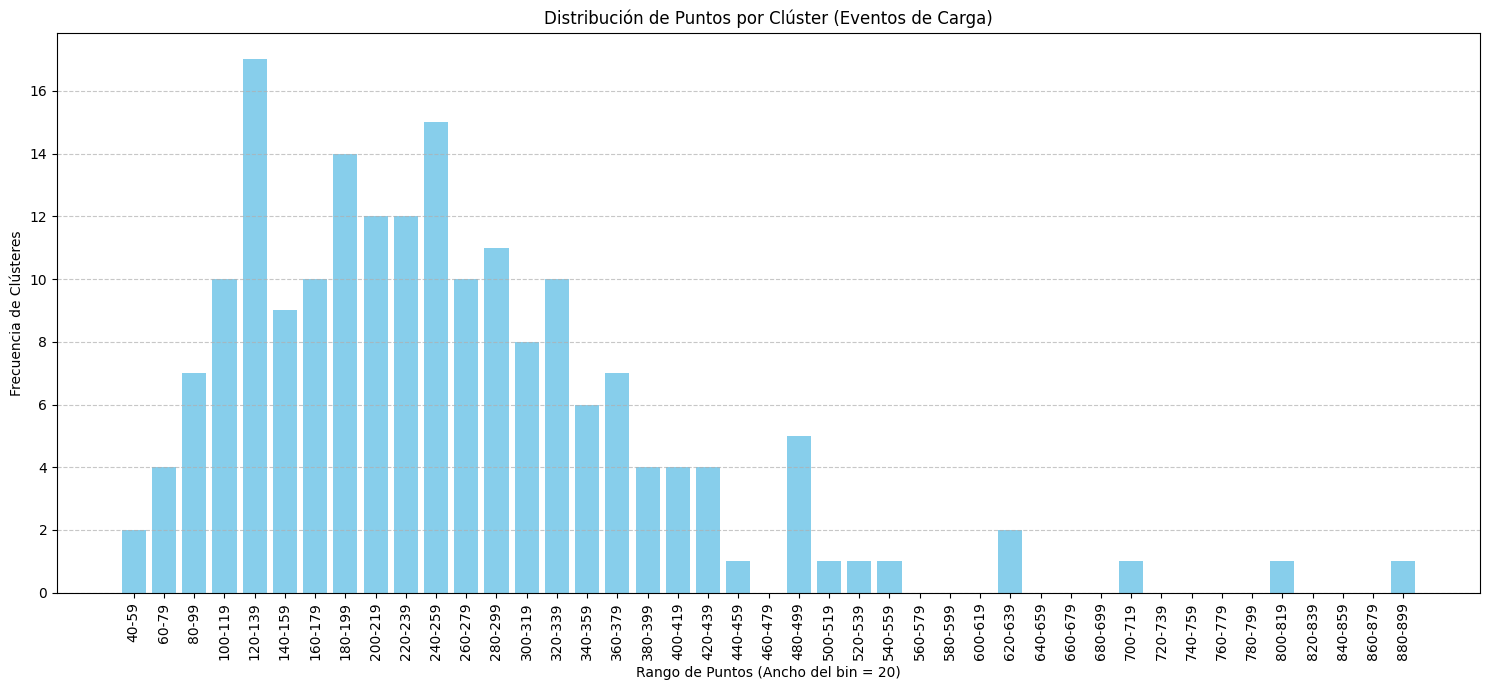

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.bar(bin_counts.index, bin_counts.values, color='skyblue')
plt.xlabel('Rango de Puntos (Ancho del bin = 20)')
plt.ylabel('Frecuencia de Clústeres')
plt.title('Distribución de Puntos por Clúster (Eventos de Carga)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Este gráfico de barras (histograma) visualiza la distribución de los tamaños de clústeres. El eje X muestra los rangos de puntos (ej. 40-59 puntos, 60-79 puntos), y el eje Y muestra la frecuencia, es decir, cuántos clústeres tienen ese número de puntos. Esto ayuda a comprender si hay muchos clústeres pequeños o grandes, o si la distribución es más uniforme.

In [ ]:
from haversine import haversine, Unit
import pandas as pd

# Función que devuelve el tiempo máximo en segundos según el tipo de distancia
def wait(dis):
    if dis == 'corto':
        return 300  # 5 minutos en segundos
    elif dis == 'medio':
        return 420  # 7 minutos en segundos
    else:
        return 600  # 10 minutos en segundos

# Función que calcula la distancia máxima que una persona puede caminar
# usando una velocidad de 5 km/h
def max_distance(time_sec):
    # 5 km/h -> 5000 metros por hora -> 83.33 metros por minuto -> 1.39 metros por segundo
    velocity = 5 * 1000 / 3600  # 5 km/h en metros por segundo
    return velocity * time_sec  # Distancia máxima en metros

# Lista para almacenar los viajes perdidos según los criterios
lost_trips = []

# Total de puntos en combined_coords_df
total_points = len(combined_coords_df)

# Recorrer cada par de origen y destino (los primeros 24000 son orígenes, el resto son destinos)
for i in range(total_points // 2):
    # Origen (primer mitad de los puntos)
    origin_row = combined_coords_df.iloc[i]
    origin_lat = origin_row["lat"]
    origin_lon = origin_row["lon"]
    origin_type = origin_row["type"]  # tipo de distancia (corto, medio, largo)
    origin_cluster = origin_row["clusterFinal"]  # cluster al que pertenece el origen

    # Obtener las coordenadas del centroide del cluster de origen
    origin_cluster_row = centroides_new[centroides_new['cluster'] == origin_cluster].iloc[0]
    origin_cluster_lat = origin_cluster_row["lat"]
    origin_cluster_lon = origin_cluster_row["lon"]

    # Destino (segunda mitad de los puntos)
    destination_row = combined_coords_df.iloc[i + total_points // 2]
    dest_lat = destination_row["lat"]
    dest_lon = destination_row["lon"]
    dest_type = destination_row["type"]  # tipo de distancia (corto, medio, largo)
    dest_cluster = destination_row["clusterFinal"]  # cluster al que pertenece el destino

    # Obtener las coordenadas del centroide del cluster de destino
    dest_cluster_row = centroides_new[centroides_new['cluster'] == dest_cluster].iloc[0]
    dest_cluster_lat = dest_cluster_row["lat"]
    dest_cluster_lon = dest_cluster_row["lon"]

    # Obtener el tiempo máximo de espera (dependiendo del tipo de distancia)
    max_wait_time = wait(origin_type)  # Usamos el tipo de distancia del origen

    # Calcular la distancia máxima caminable
    max_walk_distance = max_distance(max_wait_time)

    # Calcular la distancia entre el origen y su centroide de cluster
    origin_distance_to_cluster = haversine((origin_lat, origin_lon), (origin_cluster_lat, origin_cluster_lon), unit=Unit.METERS)

    # Calcular la distancia entre el destino y su centroide de cluster
    dest_distance_to_cluster = haversine((dest_lat, dest_lon), (dest_cluster_lat, dest_cluster_lon), unit=Unit.METERS)

    # Verificar si el origen o el destino están fuera del alcance caminable
    if origin_distance_to_cluster > max_walk_distance or dest_distance_to_cluster > max_walk_distance:
        lost_trips.append({
            'origin_cluster': origin_cluster,
            'destination_cluster': dest_cluster,
            'origin_lat': origin_lat,
            'origin_lon': origin_lon,
            'destination_lat': dest_lat,
            'destination_lon': dest_lon,
            'origin_distance': origin_distance_to_cluster,
            'destination_distance': dest_distance_to_cluster,
            'max_walk_distance': max_walk_distance,
            'reason': 'Exceeds maximum walkable distance'
        })

    # También considerar el viaje como perdido si el origen y el destino están en el mismo cluster
    elif origin_cluster == dest_cluster:
        lost_trips.append({
            'origin_cluster': origin_cluster,
            'destination_cluster': dest_cluster,
            'origin_lat': origin_lat,
            'origin_lon': origin_lon,
            'destination_lat': dest_lat,
            'destination_lon': dest_lon,
            'origin_distance': 'N/A',  # No se calcula la distancia, ya que es un viaje perdido por el mismo cluster
            'destination_distance': 'N/A',
            'max_walk_distance': 'N/A',
            'reason': 'Same origin and destination cluster'
        })

# Convertir la lista de viajes perdidos en un DataFrame
lost_trips_df = pd.DataFrame(lost_trips)

# Mostrar el número total de viajes perdidos
total_lost = len(lost_trips_df)
total_trips = total_points // 2  # Número total de viajes (ya que hay un origen y un destino por viaje)
proportion_lost = total_lost / total_trips * 100

print(f"Total de viajes perdidos: {total_lost}")
print(f"Proporción de viajes perdidos: {proportion_lost:.2f}%")

# Mostrar los primeros 5 viajes perdidos
lost_trips_df.head()

Esta es una de las partes cruciales de la evaluación. La función calcula dos tipos de "viajes perdidos":

1.  **Viajes fuera del radio caminable**: Si la distancia entre el origen o el destino del viaje y el centroide de su clúster asignado es mayor que la `max_walk_distance` (calculada en base al tiempo de espera y una velocidad de caminata de 5 km/h).
2.  **Viajes con origen y destino en el mismo clúster**: Estos viajes se consideran "perdidos" o "no cubiertos" por el sistema de estaciones, ya que implica que la persona podría haber realizado el viaje sin necesidad de una estación si ambos puntos están tan cerca que caen en la misma. Esto ayuda a filtrar viajes potencialmente ineficientes para el servicio de flota.

El resultado es un DataFrame `lost_trips_df` que lista todos los viajes que caen en estas categorías, junto con la proporción total de viajes perdidos.

In [ ]:
df = df.merge(combined_coords_df[['lon', 'lat', 'clusterFinal']],
              left_on=['lonO', 'latO'],
              right_on=['lon', 'lat'],
              how='left')
print(f"Número de filas después del primer merge: {len(df)}")

# Renombrar la columna 'clusterFinal' obtenida del merge para 'clusterOrigen'
df.rename(columns={'clusterFinal': 'clusterOrigen'}, inplace=True)

# Merge para asignar clusterFinal basado en las coordenadas de destino (lonD, latD)
df = df.merge(combined_coords_df[['lon', 'lat', 'clusterFinal']],
              left_on=['lonD', 'latD'],
              right_on=['lon', 'lat'],
              how='left')

# Renombrar la columna 'clusterFinal' obtenida del merge para 'clusterFinal'
df.rename(columns={'clusterFinal': 'clusterFinal'}, inplace=True)
print(f"Número de filas después del primer merge: {len(df)}")

# Mostrar el resultado
df


In [ ]:
df = df.drop_duplicates(subset=['lonO',	'latO',	'lonD'	,'latD'])


In [ ]:
df = df.drop(columns=['lon_x', 'lat_x', 'lon_y', 'lat_y'])


In [ ]:
# Realizar un merge entre df y lost_trips para encontrar las filas coincidentes
merged_df = df.merge(lost_trips_df[['origin_lat', 'origin_lon', 'destination_lat', 'destination_lon']],
                     left_on=['latO', 'lonO', 'latD', 'lonD'],
                     right_on=['origin_lat', 'origin_lon', 'destination_lat', 'destination_lon'],
                     how='left', indicator=True)

# Filtrar aquellas filas que no están en lost_trips (es decir, las filas donde el indicador no es 'both')
df_final = merged_df[merged_df['_merge'] == 'left_only'].drop(columns=['_merge'])

# Mostrar el DataFrame limpio
df_final




Aquí, integramos la información de `clusterFinal` (el clúster asignado a cada punto de origen y destino) de vuelta al DataFrame original `df`. Esto se realiza mediante dos operaciones de `merge`:

1.  El primer `merge` asigna el `clusterFinal` a los puntos de origen (`lonO`, `latO`), renombrando la columna resultante a `clusterOrigen`.
2.  El segundo `merge` asigna el `clusterFinal` a los puntos de destino (`lonD`, `latD`), renombrando la columna a `clusterFinal` (que ahora representa el clúster de destino).

In [ ]:
df_final.to_csv("potenciales_viajes_cubiertos.csv")

## Otras visualizaciones

In [26]:
import pandas as pd
import folium
import numpy as np

df=df_final
# 1. Carga tus datos (Simulación con tu estructura)
# df = pd.read_csv('tu_archivo.csv')

# 2. PREPARACIÓN DE DATOS
# Agrupamos por clúster de origen para contar cuántos viajes salen de cada uno
cluster_stats = df.groupby('clusterOrigen').agg({
    'idS': 'count',                   # Contamos viajes
    'Lat ClusterOrigin': 'first',     # Tomamos la latitud del centroide (es igual para todo el grupo)
    'Lon ClusterOrigin': 'first'      # Tomamos la longitud del centroide
}).reset_index()

cluster_stats.rename(columns={'idS': 'num_viajes'}, inplace=True)

# 3. CREACIÓN DEL MAPA
# Centrado en Roma
m = folium.Map(location=[41.9028, 12.4964], zoom_start=12, tiles='CartoDB positron')

# 4. AÑADIR BURBUJAS
# Definimos una escala para que los círculos no sean ni gigantes ni invisibles
# Ajusta este 'scale_factor' según necesites verlos más grandes o chicos
scale_factor = 1.5
azul_borde = '#005a8d'   # Un azul más oscuro para el borde
azul_relleno = '#0078d7' # Un azul brillante para el relleno
for i, row in cluster_stats.iterrows():
    # Evitar clústeres vacíos o errores de nulos
    if pd.notnull(row['Lat ClusterOrigin']):

        # El radio es la raíz cuadrada del conteo para que el área sea proporcional (visualización correcta)
        radius_size = np.sqrt(row['num_viajes']) * scale_factor

        folium.CircleMarker(
            location=[row['Lat ClusterOrigin'], row['Lon ClusterOrigin']],
            radius=radius_size,
            color=azul_borde,     # Un verde "Spotify" o eléctrico resalta mucho en mapa oscuro
            fill=True,
            fill_color=azul_relleno,
            fill_opacity=0.6,
            weight=1,             # Sin borde para que se vea más moderno
            popup=folium.Popup(f"<b>Cluster:</b> {int(row['clusterOrigen'])}<br><b>Viajes:</b> {row['num_viajes']}", max_width=200),
            tooltip=f"Cluster {int(row['clusterOrigen'])}: {row['num_viajes']} viajes"
        ).add_to(m)

# Guardar o mostrar
m.save('mapa_clusters_roma.html')
m

In [ ]:
pip install keplergl

In [ ]:
from keplergl import KeplerGl
from google.colab import files


df=pd.read_csv("viajes_potenciales_con_distancias.csv")
map_1 = KeplerGl(height=800)

map_1.add_data(data=df, name='Viajes Roma')

nombre_archivo = 'Mapa_Roma_Kepler.html'
map_1.save_to_html(file_name=nombre_archivo)

# 3. Forzamos la descarga a tu ordenador
files.download(nombre_archivo)